In [2]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

from xgboost import XGBClassifier
import shap
import warnings

warnings.filterwarnings('ignore', category=RuntimeWarning)

## Investigating Exclusion of Counties that have Existing Plants

In [3]:
final_data = Path.cwd().parent.parent.joinpath('processed_data', 'final_dataset.csv')
candidates_data = Path.cwd().parent.parent.joinpath('processed_data', 'candidates.csv')

In [4]:
# reading final_dataset.csv and candidates.csv
df_final = pd.read_csv(final_data)
df_candidates = pd.read_csv(candidates_data)

In [5]:
# motivating validation more . . .
# identifying plants that survived or were excluded by masking
has_plant = df_final[df_final['plant_count'] > 0]
survived = has_plant[has_plant['geo_id'].isin(df_candidates['geo_id'])]
excluded = has_plant[~has_plant['geo_id'].isin(df_candidates['geo_id'])]

print(f'Plant counties in full dataset: {len(has_plant)}')
print(f'Plant counties surviving masking: {len(survived)}')
print(f'Plant counties excluded by maksing: {len(excluded)}')

Plant counties in full dataset: 54
Plant counties surviving masking: 42
Plant counties excluded by maksing: 12


In [6]:
# finding exclusion reasons
def exclusion_reason(county):
    reasons = []
    if county['pga_max'] > 0.3:
        reasons.append(f'seismic (pga_max={county['pga_max']:.4f})')
    if county['pct_sfha'] > 0.2:
        reasons.append(f'flood (pct_sfha={county['pct_sfha']:.4f})')
    if county['pct_military'] > 0.1:
        reasons.append(f'military (pct_military={county['pct_military']:.4f})')
    if county['pct_protected'] > 0.1:
        reasons.append(f'protected (pct_protected={county['pct_protected']:.4f})')
    return ', '.join(reasons)

excluded = excluded.copy()
excluded['exclusion_reason'] = excluded.apply(exclusion_reason, axis=1)
with pd.option_context('display.max_colwidth', None):
    display(excluded[['county_name', 'exclusion_reason']])

,county_name,exclusion_reason
118,Matagorda County,flood (pct_sfha=0.4517)
464,Coffey County,flood (pct_sfha=0.2101)
691,West Feliciana Parish,flood (pct_sfha=0.3915)
926,Claiborne County,flood (pct_sfha=0.2020)
939,Miami-Dade County,"flood (pct_sfha=0.4680), protected (pct_protected=0.4706)"
1779,San Luis Obispo County,"seismic (pga_max=0.5300), protected (pct_protected=0.1626)"
1918,Maricopa County,"military (pct_military=0.1233), protected (pct_protected=0.1393)"
2197,Brunswick County,flood (pct_sfha=0.3282)
2582,Nemaha County,flood (pct_sfha=0.2122)
2849,Hamilton County,seismic (pga_max=0.3200)


In [7]:
exclusion_counts = {'Seismic': (has_plant['pga_max'] > 0.3).sum(),
                    'Flood': (has_plant['pct_sfha'] > 0.2).sum(),
                    'Military': (has_plant['pct_military'] > 0.1).sum(),
                    'Protected': (has_plant['pct_protected'] > 0.1).sum()}
exclusion_counts

{'Seismic': np.int64(2),
 'Flood': np.int64(9),
 'Military': np.int64(1),
 'Protected': np.int64(4)}

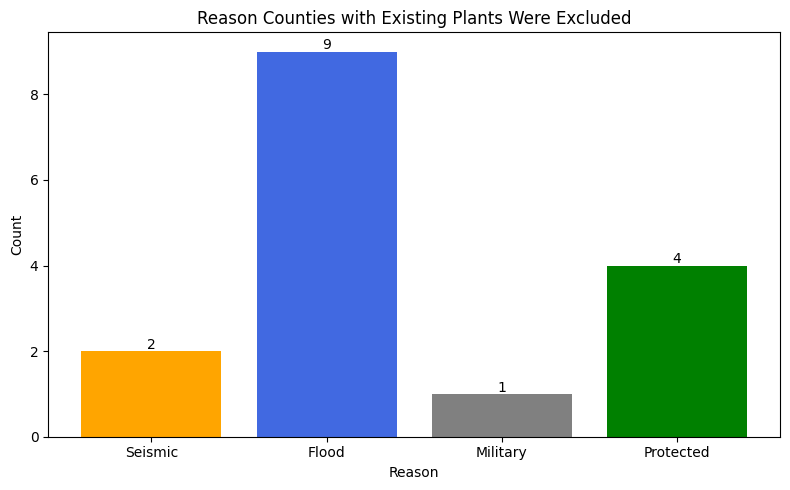

In [8]:
# bar graph of count of reasons why counties with existing plants were excluded

plt.figure(figsize=(8, 5))
plt.bar(exclusion_counts.keys(), exclusion_counts.values(), color=['orange', 'royalblue', 'gray', 'green'])
plt.title('Reason Counties with Existing Plants Were Excluded')
plt.ylabel('Count')
plt.xlabel('Reason')
for i, (k, v) in enumerate(exclusion_counts.items()):
    plt.text(i, v + 0.05, str(v), ha='center')
plt.tight_layout()
plt.show()

## Extracting Feature Importance

In [9]:
candidates_ranked_data = Path.cwd().parent.parent.joinpath('processed_data', 'candidates_ranked.csv')
candidates_ranked_data

WindowsPath('c:/Users/walte/team-nuclear-family/processed_data/candidates_ranked.csv')

In [10]:
df = pd.read_csv(candidates_ranked_data)
df.head()

,geo_id,county_name,population,median_household_income,housing_units,total_energy_consumption_mwh,data_centers_count,sfha_area,pct_sfha,lake_count,...,max_voltage,average_voltage,protected_count,total_protected_area_m,pct_protected,county_area_km2,population_density,has_plant,mcda_score,rank
0,40075,Kiowa County,8181.0,42679.0,4700.0,157935.0,0.0,2.112674e+08,0.079146,10,...,138.0,110.400000,2.0,4.108833e+07,0.015393,2669.336760,3.064806,0,0.529671,1880.0
1,46079,Lake County,10993.0,74884.0,5714.0,170505.0,0.0,1.890356e+08,0.126898,48,...,69.0,69.000000,156.0,1.136746e+08,0.076309,1489.662955,7.379522,0,0.591694,1349.0
2,37033,Caswell County,22563.0,56999.0,10493.0,295896.0,0.0,6.618573e+07,0.059609,4,...,230.0,230.000000,16.0,1.409890e+07,0.012698,1110.336635,20.320864,0,0.637095,799.0
3,48377,Presidio County,5433.0,29012.0,3396.0,106309.0,0.0,0.000000e+00,0.000000,0,...,69.0,69.000000,16.0,3.486332e+08,0.034909,9986.831983,0.544016,0,0.585314,1404.0
4,39057,Greene County,174322.0,81243.0,71471.0,2239244.0,0.0,1.002618e+08,0.092999,8,...,345.0,112.909091,58.0,1.130754e+07,0.010488,1078.100699,161.693616,0,0.596162,1284.0


In [11]:
# from scoring.ipynb:
# some variables are better if they have a higher value
# while others are better if they have a lower value

higher_better = [
    "avg_vol",
    "total_lake_area", 
    "max_voltage",
    "total_energy_consumption_mwh",
    "data_centers_count"
]

lower_better = [
    "pga_max",
    "pct_sfha",
    "population_density",
    "dist_to_lakes_km",
    "distance_to_lines_km",
    "pct_military",
    "pct_protected",
]

scored_features = higher_better + lower_better
scored_features

['avg_vol',
 'total_lake_area',
 'max_voltage',
 'total_energy_consumption_mwh',
 'data_centers_count',
 'pga_max',
 'pct_sfha',
 'population_density',
 'dist_to_lakes_km',
 'distance_to_lines_km',
 'pct_military',
 'pct_protected']

In [12]:
# places with no mcda_score
df[df['mcda_score'].isna()]

,geo_id,county_name,population,median_household_income,housing_units,total_energy_consumption_mwh,data_centers_count,sfha_area,pct_sfha,lake_count,...,max_voltage,average_voltage,protected_count,total_protected_area_m,pct_protected,county_area_km2,population_density,has_plant,mcda_score,rank
155,78030,St. Thomas Island,NaN,NaN,NaN,NaN,0.0,4.057066e+07,0.050775,1,...,0.0,0.000000,20.0,2.299731e+06,0.002878,799.030691,NaN,0,NaN,NaN
226,60040,Swains Island,NaN,NaN,NaN,NaN,0.0,0.000000e+00,0.000000,1,...,0.0,0.000000,0.0,0.000000e+00,0.000000,151.603053,NaN,0,NaN,NaN
297,66010,Guam,NaN,NaN,NaN,NaN,0.0,9.705555e+07,0.065672,1,...,0.0,0.000000,13.0,1.108224e+08,0.074987,1477.893555,NaN,0,NaN,NaN
325,69100,Rota Municipality,NaN,NaN,NaN,NaN,0.0,4.917306e+06,0.007878,0,...,0.0,0.000000,0.0,0.000000e+00,0.000000,624.189588,NaN,0,NaN,NaN
846,69110,Saipan Municipality,NaN,NaN,NaN,NaN,0.0,1.852848e+07,0.028433,1,...,0.0,0.000000,0.0,0.000000e+00,0.000000,651.656085,NaN,0,NaN,NaN
854,9110,Capitol Planning Region,994115.0,88190.0,413960.0,NaN,1.0,1.954939e+08,0.072148,53,...,345.0,141.285714,1114.0,1.005055e+08,0.037092,2709.608749,366.885072,0,NaN,NaN
855,9120,Greater Bridgeport Planning Region,337697.0,83147.0,125378.0,NaN,1.0,6.009566e+07,0.097426,10,...,345.0,125.000000,73.0,1.494759e+07,0.024233,616.832049,547.469932,0,NaN,NaN
856,9130,Lower Connecticut River Valley Planning Region,177311.0,99742.0,82618.0,NaN,0.0,1.643571e+08,0.122696,35,...,345.0,191.666667,711.0,8.471923e+07,0.063245,1339.543612,132.366724,0,NaN,NaN
857,9140,Naugatuck Valley Planning Region,463349.0,82939.0,191666.0,NaN,0.0,4.851334e+07,0.044432,30,...,345.0,119.893617,337.0,3.754786e+07,0.034389,1091.854238,424.368917,0,NaN,NaN
858,9150,Northeastern Connecticut Planning Region,98096.0,83119.0,41503.0,NaN,0.0,6.902615e+07,0.047325,47,...,345.0,161.000000,192.0,4.674583e+07,0.032049,1458.569142,67.254954,0,NaN,NaN


In [13]:
# dropping places with no mcda_score
df = df.dropna(subset=['mcda_score'])
print(f'Total candidates: {len(df)}')
print(f'Has plant: {df["has_plant"].sum()}')
print(f'No plant:  {(df["has_plant"]==0).sum()}')

Total candidates: 2141
Has plant: 41
No plant:  2100


Southeastern Connecticut Planning Region, which has an operating nuclear plant, was dropped as it does not have an mcda_score due to no total energy consumption data for it in our dataset. This can be something to investigate.

### Decision Tree

In [14]:
# checking for null values in scored features
print(df[scored_features].isna().sum().sum())

0


In [15]:
# creating features and target
from sklearn.pipeline import Pipeline
X = df[scored_features]
y = df['has_plant']

# creating train and test data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=207)

In [16]:
# cross validation
# class_weight='balanced' to handle class imbalance
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=207)
tree = DecisionTreeClassifier(class_weight='balanced', random_state=207)

# creating pipeline
pipeline = Pipeline([('scaler', MinMaxScaler()), ('tree', tree)])

cv_scores = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring='f1')
print(f'Baseline F1: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')

Baseline F1: 0.0267 ± 0.0533


In [17]:
# grid search
params = {'tree__max_depth': [3, 5, 7, 10, None], 'tree__min_samples_split': [2, 5, 10], 'tree__min_samples_leaf': [1, 2, 4], 'tree__criterion': ['gini', 'entropy'], 'tree__max_features': ['sqrt', 'log2', None]}
grid_search = GridSearchCV(pipeline, params, cv=cv, scoring='f1', n_jobs=-1)
grid_search.fit(X_train, y_train)

print('Best params:', grid_search.best_params_)
print('Best F1:', grid_search.best_score_)
print('Best CV std:', grid_search.cv_results_['std_test_score'][grid_search.best_index_])

Best params: {'tree__criterion': 'gini', 'tree__max_depth': None, 'tree__max_features': 'sqrt', 'tree__min_samples_leaf': 1, 'tree__min_samples_split': 2}
Best F1: 0.12080808080808081
Best CV std: 0.09946618053026188


After grid search, F1 score is still low. This suggests that the features used may not strongly predict historical plant siting.

In [18]:
# tree with best params
best_tree = grid_search.best_estimator_

y_pred = best_tree.predict(X_test)
print(classification_report(y_test, y_pred, target_names=['No plant', 'Has plant']))

              precision    recall  f1-score   support

    No plant       0.98      0.97      0.97       421
   Has plant       0.07      0.12      0.09         8

    accuracy                           0.95       429
   macro avg       0.52      0.55      0.53       429
weighted avg       0.97      0.95      0.96       429



Precision and recall for 'has plant' is low, so the tree flagged many counties with no operating plants as ones that do and flagged many counties with operating plants as ones that don't.

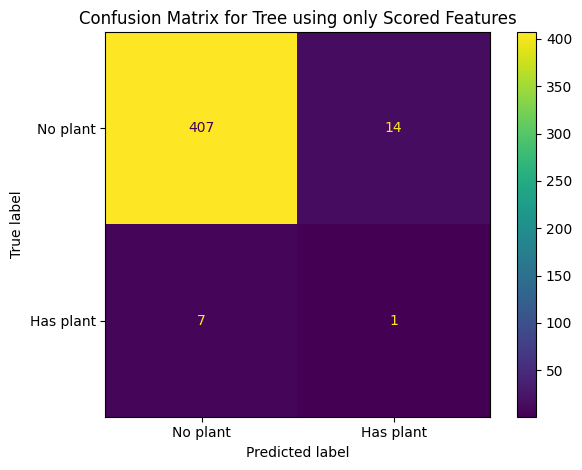

In [19]:
# Confusion matrix
ConfusionMatrixDisplay.from_estimator(best_tree, X_test, y_test, display_labels=['No plant', 'Has plant'])
plt.title('Confusion Matrix for Tree using only Scored Features')
plt.tight_layout()
plt.show()

In [20]:
# feature importances
tree_importances = pd.DataFrame({'feature': scored_features, 'importance': (best_tree.named_steps['tree'].feature_importances_).round(9)}).sort_values('importance', ascending=False)
tree_importances

,feature,importance
3,total_energy_consumption_mwh,0.190330
0,avg_vol,0.155375
2,max_voltage,0.118847
7,population_density,0.116760
9,distance_to_lines_km,0.115223
11,pct_protected,0.082255
1,total_lake_area,0.080514
5,pga_max,0.062919
6,pct_sfha,0.036390
8,dist_to_lakes_km,0.021133


`data_centers_count` and `pct_military` have low importances, possibly suggesting these weren't important factors for siting historical plants or may be highly correlated with other variables.

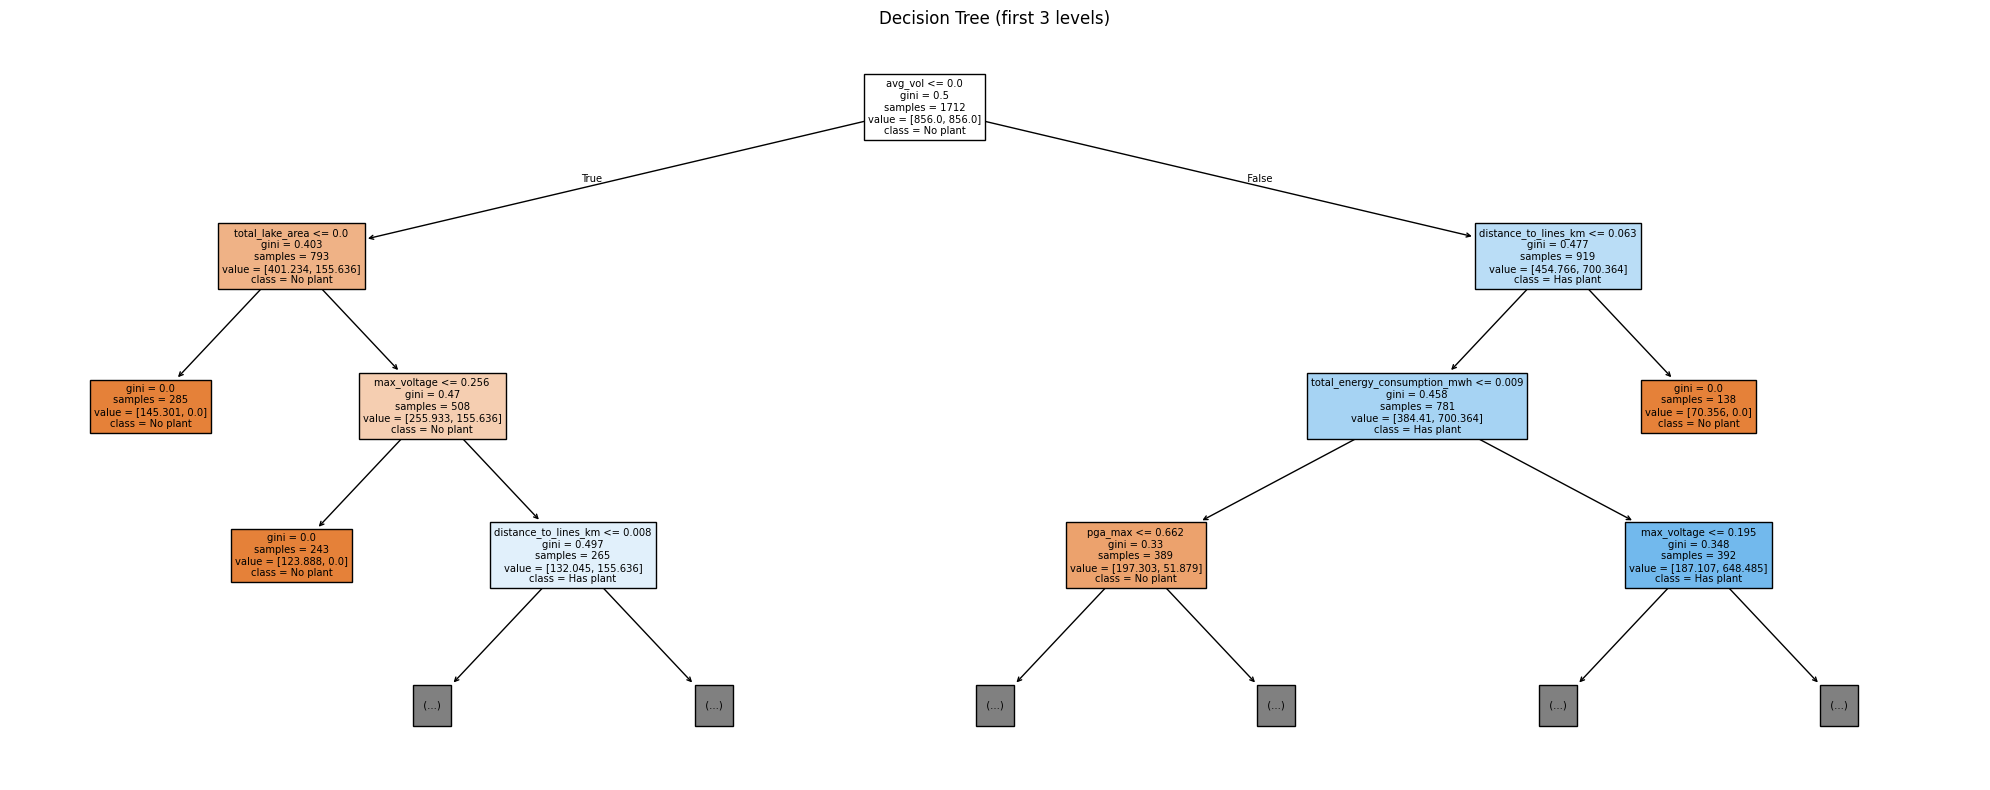

In [21]:
# visualize the tree
plt.figure(figsize=(20, 8))
plot_tree(
    best_tree.named_steps['tree'],
    feature_names=scored_features,
    class_names=['No plant', 'Has plant'],
    filled=True,
    max_depth=3
)
plt.title('Decision Tree (first 3 levels)')
plt.tight_layout()
plt.show()

In [22]:
# Definining decision tree function to use on different dataframes and features
    # returns best tree (pipeline), importances dataframe, and classification report
def make_decision_tree(df: pd.DataFrame, features: list, params: dict):
    """ 
    Returns: 
    
    best_tree: Pipeline

    tree_importances: pd.Dataframe

    report: dict
    """
    df = df.dropna(subset=features)
    # features and target
    X = df[features]
    y = df['has_plant']

    # split into train and test
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=207)

    # cross validation
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=207)
    tree = DecisionTreeClassifier(class_weight='balanced', random_state=207)
    pipeline = Pipeline([('scaler', MinMaxScaler()), ('tree', tree)])
    cv_scores = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring='f1')
    print(f'Baseline F1: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')

    # add tree__ prefix before each of the params
    prefixed_params = {f'tree__{k}': v for k, v in params.items()}

    # grid search
    grid_search = GridSearchCV(pipeline, prefixed_params, cv=cv, scoring='f1', n_jobs=-1)
    grid_search.fit(X_train, y_train)
    print('Best params:', grid_search.best_params_)
    print('Best F1:', grid_search.best_score_)
    print('Best CV std:', grid_search.cv_results_['std_test_score'][grid_search.best_index_])

    # fit and evaluate on test data
    best_tree = grid_search.best_estimator_
    y_pred = best_tree.predict(X_test)
    report = classification_report(y_test, y_pred, target_names=['No plant', 'Has plant'], output_dict=True)
    print(classification_report(y_test, y_pred, target_names=['No plant', 'Has plant']))

    '''
    # confusion matrix
    ConfusionMatrixDisplay.from_estimator(best_tree, X_test, y_test, display_labels=['No plant', 'Has plant'])
    plt.title('Confusion Matrix')
    plt.tight_layout()
    plt.show()
    '''

    # feature importances
    tree_importances = pd.DataFrame({'feature': features, 'importance': (best_tree.named_steps['tree'].feature_importances_).round(9)}).sort_values('importance', ascending=False)

    return best_tree, tree_importances, report

In [23]:
params = {'max_depth': [3, 5, 7, 10, None], 'min_samples_split': [2, 5, 10], 
              'min_samples_leaf': [1, 2, 4], 'criterion': ['gini', 'entropy'], 
              'max_features': ['sqrt', 'log2', None]}
best_tree_all_vars, importances_all_vars, report = make_decision_tree(df, df.columns.drop(['geo_id', 'county_name', 'plant_count', 'has_plant', 'mcda_score', 'rank']).to_list(), params)
importances_all_vars

Baseline F1: 0.0802 ± 0.0658
Best params: {'tree__criterion': 'entropy', 'tree__max_depth': None, 'tree__max_features': 'log2', 'tree__min_samples_leaf': 1, 'tree__min_samples_split': 10}
Best F1: 0.14357142857142857
Best CV std: 0.084225159845621
              precision    recall  f1-score   support

    No plant       0.98      0.96      0.97       420
   Has plant       0.00      0.00      0.00         8

    accuracy                           0.94       428
   macro avg       0.49      0.48      0.48       428
weighted avg       0.96      0.94      0.95       428



,feature,importance
3,total_energy_consumption_mwh,0.208564
29,population_density,0.085360
23,max_voltage,0.080049
10,avg_depth,0.073351
8,total_lake_area,0.061825
16,total_rivers_mile,0.061057
13,wetland_count,0.058067
24,average_voltage,0.054931
9,avg_vol,0.050810
5,sfha_area,0.046041


Both decision trees so far put `total_energy_consumption_mwh` as the most important feature.
The decision tree using all features predicts none of the counties with operating plants correctly. Removing None from max_depth possibilities since None gets chosen and may cause overfitting.

In [24]:
# comparing scored_features vs. all features with and without max_depth=None in grid search

# have scored_features from before
all_features = df.columns.drop(['geo_id', 'county_name', 'plant_count', 'has_plant', 'mcda_score', 'rank']).to_list()

params_with_max_depth_none = {'max_depth': [3, 5, 7, 10, None], 'min_samples_split': [2, 5, 10], 
              'min_samples_leaf': [1, 2, 4], 'criterion': ['gini', 'entropy'], 
              'max_features': ['sqrt', 'log2', None]}
params_without_max_depth_none = params = {'max_depth': [3, 5, 7, 10], 'min_samples_split': [2, 5, 10], 
              'min_samples_leaf': [1, 2, 4], 'criterion': ['gini', 'entropy'], 
              'max_features': ['sqrt', 'log2', None]}

print("Scored features with max_depth=None in grid search: ")
_, importances_scored_with, report_scored_with = make_decision_tree(df, scored_features, params_with_max_depth_none)
print("Scored features without max_depth=None in grid search: ")
_, importances_scored_without, report_scored_without = make_decision_tree(df, scored_features, params_without_max_depth_none)
print("All features with max_depth=None in grid search: ")
_, importances_all_with, report_all_with = make_decision_tree(df, all_features, params_with_max_depth_none)
print("All features without max_depth=None in grid search: ")
_, importances_all_without, report_all_without = make_decision_tree(df, all_features, params_without_max_depth_none)

Scored features with max_depth=None in grid search: 
Baseline F1: 0.0267 ± 0.0533
Best params: {'tree__criterion': 'gini', 'tree__max_depth': None, 'tree__max_features': 'sqrt', 'tree__min_samples_leaf': 1, 'tree__min_samples_split': 2}
Best F1: 0.12080808080808081
Best CV std: 0.09946618053026188
              precision    recall  f1-score   support

    No plant       0.98      0.97      0.97       421
   Has plant       0.07      0.12      0.09         8

    accuracy                           0.95       429
   macro avg       0.52      0.55      0.53       429
weighted avg       0.97      0.95      0.96       429

Scored features without max_depth=None in grid search: 
Baseline F1: 0.0267 ± 0.0533
Best params: {'tree__criterion': 'entropy', 'tree__max_depth': 10, 'tree__max_features': 'sqrt', 'tree__min_samples_leaf': 1, 'tree__min_samples_split': 10}
Best F1: 0.11352016404647984
Best CV std: 0.029320341390345388
              precision    recall  f1-score   support

    No plant  

In [25]:
comparison = pd.DataFrame([
    {
        'tree': 'Scored features with None',
        'baseline_f1': 0.0697,
        'baseline_std': 0.0855,
        'best_cv_f1': 0.1100,
        'best_cv_std': 0.1410,
        **{k: round(v, 4) for k, v in {
            'no_plant_precision': report_scored_with['No plant']['precision'],
            'no_plant_recall': report_scored_with['No plant']['recall'],
            'no_plant_f1': report_scored_with['No plant']['f1-score'],
            'has_plant_precision': report_scored_with['Has plant']['precision'],
            'has_plant_recall': report_scored_with['Has plant']['recall'],
            'has_plant_f1': report_scored_with['Has plant']['f1-score'],
        }.items()}
    },
    {
        'tree': 'Scored features without None',
        'baseline_f1': 0.0697,
        'baseline_std': 0.0855,
        'best_cv_f1': 0.1005,
        'best_cv_std': 0.0646,
        **{k: round(v, 4) for k, v in {
            'no_plant_precision': report_scored_without['No plant']['precision'],
            'no_plant_recall': report_scored_without['No plant']['recall'],
            'no_plant_f1': report_scored_without['No plant']['f1-score'],
            'has_plant_precision': report_scored_without['Has plant']['precision'],
            'has_plant_recall': report_scored_without['Has plant']['recall'],
            'has_plant_f1': report_scored_without['Has plant']['f1-score'],
        }.items()}
    },
    {
        'tree': 'All features with None',
        'baseline_f1': 0.0802,
        'baseline_std': 0.0658,
        'best_cv_f1': 0.175,
        'best_cv_std': 0.105,
        **{k: round(v, 4) for k, v in {
            'no_plant_precision': report_all_with['No plant']['precision'],
            'no_plant_recall': report_all_with['No plant']['recall'],
            'no_plant_f1': report_all_with['No plant']['f1-score'],
            'has_plant_precision': report_all_with['Has plant']['precision'],
            'has_plant_recall': report_all_with['Has plant']['recall'],
            'has_plant_f1': report_all_with['Has plant']['f1-score'],
        }.items()}
    },
    {
        'tree': 'All features without None',
        'baseline_f1': 0.0802,
        'baseline_std': 0.0658,
        'best_cv_f1': 0.1459,         
        'best_cv_std': 0.0451,        
        **{k: round(v, 4) for k, v in {
            'no_plant_precision': report_all_without['No plant']['precision'],
            'no_plant_recall': report_all_without['No plant']['recall'],
            'no_plant_f1': report_all_without['No plant']['f1-score'],
            'has_plant_precision': report_all_without['Has plant']['precision'],
            'has_plant_recall': report_all_without['Has plant']['recall'],
            'has_plant_f1': report_all_without['Has plant']['f1-score'],
        }.items()}
    },
]).set_index('tree')

comparison

,baseline_f1,baseline_std,best_cv_f1,best_cv_std,no_plant_precision,no_plant_recall,no_plant_f1,has_plant_precision,has_plant_recall,has_plant_f1
tree,,,,,,,,,,
Scored features with None,0.0697,0.0855,0.1100,0.1410,0.9831,0.9667,0.9749,0.0667,0.125,0.0870
Scored features without None,0.0697,0.0855,0.1005,0.0646,0.9827,0.9454,0.9637,0.0417,0.125,0.0625
All features with None,0.0802,0.0658,0.1750,0.1050,0.9805,0.9595,0.9699,0.0000,0.000,0.0000
All features without None,0.0802,0.0658,0.1459,0.0451,0.9825,0.9357,0.9585,0.0357,0.125,0.0556


Removing None from max_depth possibilities decreases F1 score slightly but decreases std for both decision trees, which decreases instability. For the tree using all features, precision and recall for 'has plant' improves from 0.

In [26]:
# all feature importances
all_importances = pd.concat([df.reset_index(drop=True) for df in [importances_scored_with, importances_scored_without, importances_all_with, importances_all_without]], axis=1, 
          keys=["Scored features with None", "Scored features without None", "All features with None", "All features without None"]).fillna("")
all_importances.index += 1
all_importances

Scored features with None             Scored features without None  \
                         feature importance                       feature   
1   total_energy_consumption_mwh    0.19033            population_density   
2                        avg_vol   0.155375                       avg_vol   
3                    max_voltage   0.118847                   max_voltage   
4             population_density    0.11676                       pga_max   
5           distance_to_lines_km   0.115223              dist_to_lakes_km   
6                  pct_protected   0.082255          distance_to_lines_km   
7                total_lake_area   0.080514               total_lake_area   
8                        pga_max   0.062919                      pct_sfha   
9                       pct_sfha    0.03639                 pct_protected   
10              dist_to_lakes_km   0.021133  total_energy_consumption_mwh   
11                  pct_military   0.015623                  pct_military   
12            data_centers_count   0.004631            data_centers_count   
13                                                                          
14                                                                          
15                                                                          
16                                                                          
17                                                                          
18                                                                          
19                                                                          
20                                                                          
21                                                                          
22                                                                          
23                                                                          
24                                                                          
25                                                                          
26                                                                          
27                                                                          
28                                                                          
29                                                                          
30                                                                          

                     All features with None             \
   importance                       feature importance   
1    0.233859  total_energy_consumption_mwh   0.208564   
2    0.134043            population_density   0.085360   
3    0.132171                   max_voltage   0.080049   
4     0.12763                     avg_depth   0.073351   
5    0.103513               total_lake_area   0.061825   
6    0.090362             total_rivers_mile   0.061057   
7    0.084812                 wetland_count   0.058067   
8    0.034648               average_voltage   0.054931   
9    0.022409                       avg_vol   0.050810   
10   0.022202                     sfha_area   0.046041   
11   0.014352                       pga_max   0.045512   
12        0.0               protected_count   0.039479   
13                   total_protected_area_m   0.027445   
14                 transmission_lines_count   0.025772   
15                  median_household_income   0.022036   
16                                 pct_sfha   0.020062   
17                               lake_count   0.018895   
18                     distance_to_lines_km   0.010247   
19                               population   0.006175   
20                            housing_units   0.002417   
21                             rivers_count   0.001904   
22                       data_centers_count   0.000000   
23                         dist_to_lakes_km   0.000000   
24                            avg_discharge   0.000000   
25                    distance_to_

Some insights:
- `total_energy_consumption_mwh` consistently ranks as top feature for 3 of the 4 trees
- `max_voltage` also ranks high but drops for "All features - without None," possibly due to correlated variables in all features
- `data_centers_count` ranks low, with zero or near-zero importance across all trees; this may mean that it did not influence historical siting
- there is likely multicollinearity influencing the importances of variables, especially in the trees using all features


### XG Boost

In [27]:
# handles class imbalance
scale_pos_weight = (df['has_plant'] == 0).sum() / (df['has_plant'] == 1).sum()


X = df[scored_features]
y = df['has_plant']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=207)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=207)

xgb = XGBClassifier(scale_pos_weight=scale_pos_weight, random_state=207, eval_metric='logloss')
pipeline_xgb = Pipeline([('scaler', MinMaxScaler()), ('xgb', xgb)])

cv_scores_xgb = cross_val_score(pipeline_xgb, X_train, y_train, cv=cv, scoring='f1')
print(f'Baseline F1:  {cv_scores_xgb.mean():.4f} ± {cv_scores_xgb.std():.4f}')

Baseline F1:  0.0400 ± 0.0800


In [28]:
params_xgb = {'n_estimators': [100, 200, 300], 'max_depth': [3, 4, 5, 6], 'learning_rate': [0.01, 0.05, 0.1, 0.2], 'subsample': [0.6, 0.8, 1.0], 'colsample_bytree': [0.6, 0.8, 1.0]}
prefixed_params_xgb = {f'xgb__{k}': v for k,v in params_xgb.items()}

grid_search_xgb = GridSearchCV(pipeline_xgb, prefixed_params_xgb, cv=cv, scoring='f1', n_jobs=-1)
grid_search_xgb.fit(X_train, y_train)

print('Best params:', grid_search_xgb.best_params_)
print('Best F1:', grid_search_xgb.best_score_)
print('Best CV std:', grid_search_xgb.cv_results_['std_test_score'][grid_search_xgb.best_index_])

Best params: {'xgb__colsample_bytree': 0.8, 'xgb__learning_rate': 0.1, 'xgb__max_depth': 3, 'xgb__n_estimators': 100, 'xgb__subsample': 1.0}
Best F1: 0.15349157206742345
Best CV std: 0.046629788146919135


In [29]:
best_xgb = grid_search_xgb.best_estimator_
y_pred = best_xgb.predict(X_test)

print(classification_report(y_test, y_pred, target_names=['No plant', 'Has plant']))

              precision    recall  f1-score   support

    No plant       0.99      0.95      0.97       421
   Has plant       0.12      0.38      0.18         8

    accuracy                           0.93       429
   macro avg       0.55      0.66      0.57       429
weighted avg       0.97      0.93      0.95       429



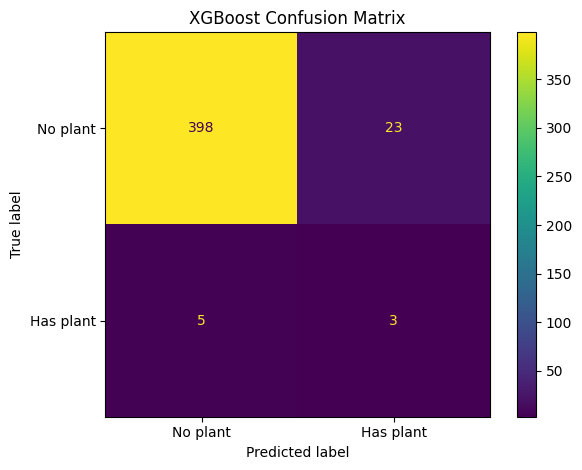

In [30]:
ConfusionMatrixDisplay.from_estimator(best_xgb, X_test, y_test, display_labels=['No plant', 'Has plant'])
plt.title('XGBoost Confusion Matrix')
plt.tight_layout()
plt.show()

In [31]:
xgb_importances = pd.DataFrame({'feature': scored_features, 'importance': best_xgb.named_steps['xgb'].feature_importances_}).sort_values('importance', ascending=False)
xgb_importances

,feature,importance
2,max_voltage,0.292733
7,population_density,0.130095
3,total_energy_consumption_mwh,0.093135
6,pct_sfha,0.074500
1,total_lake_area,0.071281
5,pga_max,0.067277
0,avg_vol,0.056180
10,pct_military,0.048927
8,dist_to_lakes_km,0.048775
11,pct_protected,0.044991


Some findings:
- Both F1 score and std improve for XGBoost compared to decision tree
- More counties with existing plants are predicted correctly
- `max_voltage` still has high importance
- `data_centers_count` has a non_zero importance although it is still the lowest of all scored_features

In [32]:
# defining function for XGBoost 
    # returns best xgb (pipeline), importances dataframe, and classification report
def make_xgboost(df: pd.DataFrame, features: list, params: dict):
    """ 
    Returns: 
    
    best_xgb: Pipeline

    tree_importances: pd.Dataframe

    report: dict
    """
    df = df.dropna(subset=features)
    
    # features and target
    X = df[features]
    y = df['has_plant']

    scale_pos_weight = (y == 0).sum() / (y == 1).sum()

    # split into train and test
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=207)

    # cross validation
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=207)
    xgb = XGBClassifier(scale_pos_weight=scale_pos_weight, random_state=207, eval_metric='logloss')
    
    pipeline_xgb = Pipeline([('scaler', MinMaxScaler()), ('xgb', xgb)])
    cv_scores = cross_val_score(pipeline_xgb, X_train, y_train, cv=cv, scoring='f1')
    print(f'Baseline F1: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')

    # add xgb__ prefix before each of the params
    prefixed_params = {f'xgb__{k}': v for k, v in params.items()}

    # grid search
    grid_search = GridSearchCV(pipeline_xgb, prefixed_params, cv=cv, scoring='f1', n_jobs=-1)
    grid_search.fit(X_train, y_train)
    print('Best params:', grid_search.best_params_)
    print('Best F1:', grid_search.best_score_)
    print('Best CV std:', grid_search.cv_results_['std_test_score'][grid_search.best_index_])

    # fit and evaluate on test data
    best_xgb = grid_search.best_estimator_
    y_pred = best_xgb.predict(X_test)
    report = classification_report(y_test, y_pred, target_names=['No plant', 'Has plant'], output_dict=True)
    print(classification_report(y_test, y_pred, target_names=['No plant', 'Has plant']))

    '''
    # confusion matrix
    ConfusionMatrixDisplay.from_estimator(best_xgb, X_test, y_test, display_labels=['No plant', 'Has plant'])
    plt.title('Confusion Matrix')
    plt.tight_layout()
    plt.show()
    '''

    # feature importances
    importances = pd.DataFrame({'feature': features, 'importance': (best_xgb.named_steps['xgb'].feature_importances_).round(9)}).sort_values('importance', ascending=False)

    return best_xgb, importances, report

In [33]:
# running xgboost on all features (runs slow)

best_xgb_all, xgb_importances_all, report_xgb_all = make_xgboost(df, all_features, params_xgb)

Baseline F1: 0.0500 ± 0.1000
Best params: {'xgb__colsample_bytree': 1.0, 'xgb__learning_rate': 0.05, 'xgb__max_depth': 3, 'xgb__n_estimators': 100, 'xgb__subsample': 0.8}
Best F1: 0.19454265541222063
Best CV std: 0.06290067914247306
              precision    recall  f1-score   support

    No plant       0.99      0.94      0.96       420
   Has plant       0.08      0.25      0.12         8

    accuracy                           0.93       428
   macro avg       0.53      0.60      0.54       428
weighted avg       0.97      0.93      0.95       428



Using all features, precision and recall dropped, likely meaning that xgboost overfitted with all the features.

In [34]:
# all feature importances - decision tree and xgboost
importances_dt_xgb = pd.concat([df.reset_index(drop=True) for df in [importances_scored_with, importances_scored_without, importances_all_with, importances_all_without, xgb_importances, xgb_importances_all]], axis=1, 
          keys=["DT: Scored features with None", "DT: Scored features without None", "DT: All features with None", "DT: All features without None", "XGBoost: Scored features", "XGBoost: All features"]).fillna("")
importances_dt_xgb.index += 1
importances_dt_xgb

DT: Scored features with None            DT: Scored features without None  \
                         feature importance                          feature   
1   total_energy_consumption_mwh    0.19033               population_density   
2                        avg_vol   0.155375                          avg_vol   
3                    max_voltage   0.118847                      max_voltage   
4             population_density    0.11676                          pga_max   
5           distance_to_lines_km   0.115223                 dist_to_lakes_km   
6                  pct_protected   0.082255             distance_to_lines_km   
7                total_lake_area   0.080514                  total_lake_area   
8                        pga_max   0.062919                         pct_sfha   
9                       pct_sfha    0.03639                    pct_protected   
10              dist_to_lakes_km   0.021133     total_energy_consumption_mwh   
11                  pct_military   0.015623                     pct_military   
12            data_centers_count   0.004631               data_centers_count   
13                                                                             
14                                                                             
15                                                                             
16                                                                             
17                                                                             
18                                                                             
19                                                                             
20                                                                             
21                                                                             
22                                                                             
23                                                                             
24                                                                             
25                                                                             
26                                                                             
27                                                                             
28                                                                             
29                                                                             
30                                                                             

                 DT: All features with None             \
   importance                       feature importance   
1    0.233859  total_energy_consumption_mwh   0.208564   
2    0.134043            population_density   0.085360   
3    0.132171                   max_voltage   0.080049   
4     0.12763                     avg_depth   0.073351   
5    0.103513               total_lake_area   0.061825   
6    0.090362             total_rivers_mile   0.061057   
7    0.084812                 wetland_count   0.058067   
8    0.034648               average_voltage   0.054931   
9    0.022409                       avg_vol   0.050810   
10   0.022202                     sfha_area   0.046041   
11   0.014352                       pga_max   0.045512   
12        0.0               protected_count   0.039479   
13                   total_protected_area_m   0.027445   
14                 transmission_lines_count   0.025772   
15                  median_household_income   0.022036   
16                                 pct_sfha   0.020062   
17                               lake_count   0.018895   
18                     distance_to_lines_km   0.010247   
19                               population   0.006175   
20                            housing_units   0.002417   
21                             rivers_count   0.001904   
22                       data_centers_count   0.000000   
23                         dist_to_lakes_km   0.00

Insights:
- `max_voltage` continues to rank high 
- `population_density` consistently ranks high for 5 of the 6 validation models
- `data_centers_count` remains having the lowest importance
- `pga_max` ranks moderately high, but not as high as number 1 (as in scoring.ipynb), suggesting that seismic risk may not have been weighted highly for historical siting

In [35]:
# using SHAP to interpret XGBoost model that uses scored features

# creating explainer
explainer = shap.TreeExplainer(best_xgb.named_steps['xgb'])
shap_explanation = explainer(pd.DataFrame(best_xgb.named_steps['scaler'].transform(X_train), columns=scored_features))

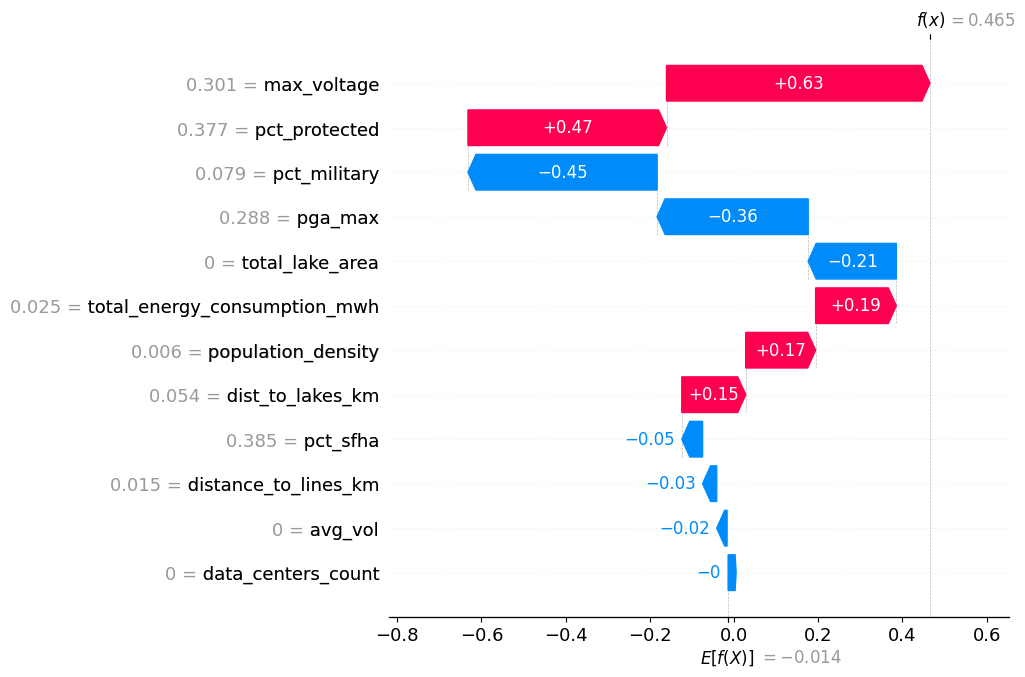

In [36]:
shap.plots.waterfall(shap_explanation[0], max_display=len(scored_features))

For this county (index 0), `pct_protected` pushing prediction toward the plant is counterintuitive here. `total_lake_area` = 0 pushes prediction away from plant; no lakes is bad!

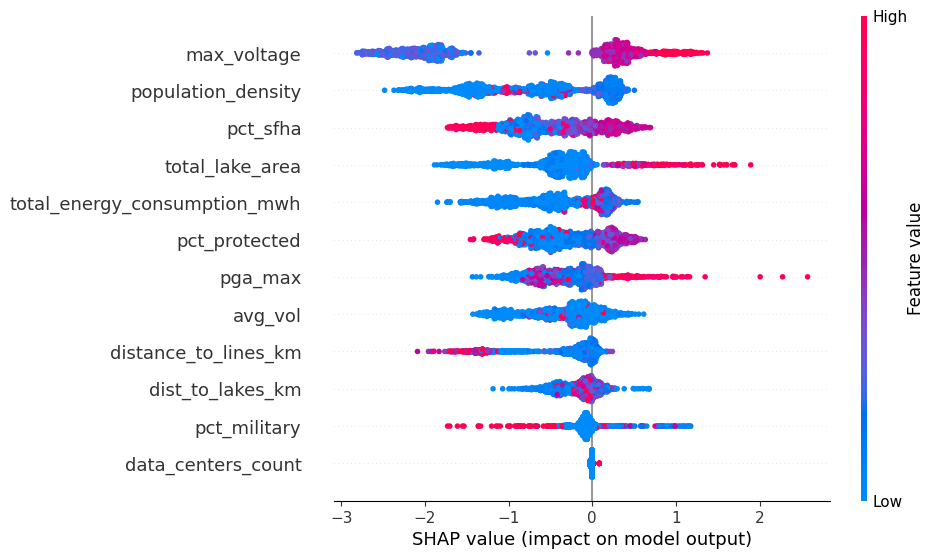

In [37]:
shap.plots.beeswarm(shap_explanation, max_display=len(scored_features))

High `max_voltage` (red dots) logically push counties toward having a plant while low `max_voltage` (blue dots) push counties toward not having a plant. There are red dots for `pct_sfha` (high flood risk) on both sides; might be because existing plants were sited near bodies of water, which have flood risk.

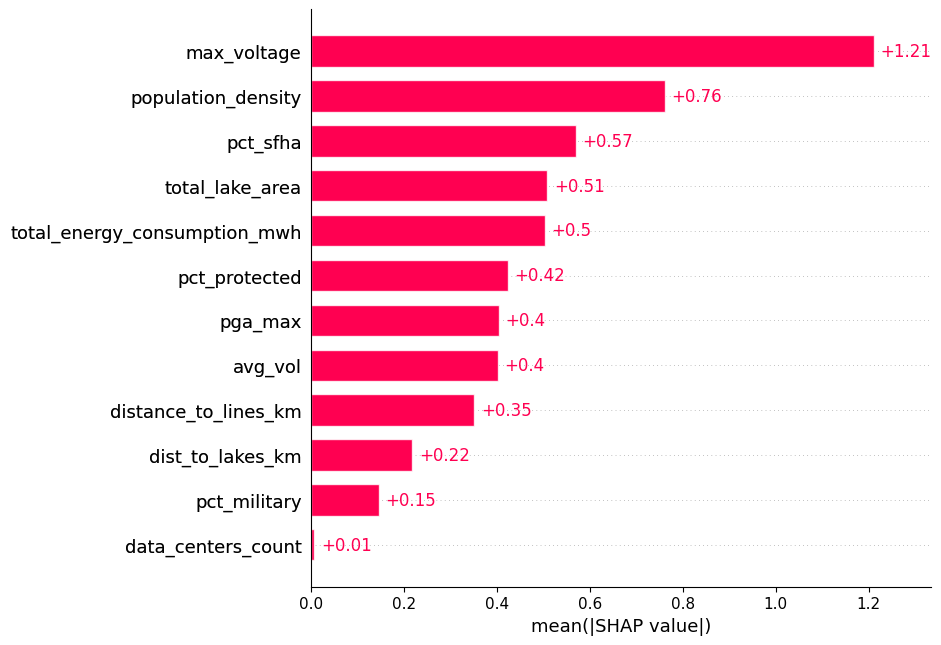

In [38]:
shap.plots.bar(shap_explanation, max_display=len(scored_features))

## OR-SAGE Regional Validation

In [39]:
# ── OR-SAGE Regional Validation ──────────────────────────────────────────
# OR-SAGE (ORNL/TM-2012/403) identifies these broad regions as most favorable
# for SMR siting based on their published composite maps and findings.
# Source: Belles et al., 2012, DOE Office of Nuclear Energy

orsage_favorable_fips = {
    # Great Lakes / Upper Midwest — OR-SAGE primary favorable region
    '55',  # Wisconsin
    '26',  # Michigan
    '27',  # Minnesota
    '39',  # Ohio
    '18',  # Indiana
    '17',  # Illinois
    # Southeast — river access, lower population density
    '47',  # Tennessee
    '37',  # North Carolina
    '45',  # South Carolina
    '13',  # Georgia
    '01',  # Alabama
    # Central Plains — low seismic, low population
    '20',  # Kansas
    '31',  # Nebraska
    '29',  # Missouri
    '19',  # Iowa
}

# extract state FIPS from county geo_id
df_ranked = df.nlargest(100, 'mcda_score').copy()
df_ranked['state_fips'] = df_ranked['geo_id'].astype(str).str.zfill(5).str[:2]

in_orsage = df_ranked['state_fips'].isin(orsage_favorable_fips)

print(f"Top 100 counties in OR-SAGE favorable regions: {in_orsage.sum()}/100")
print(f"Overlap rate: {in_orsage.mean():.1%}")
print(f"\nTop 10 counties and whether they're in OR-SAGE favorable regions:")
print(df_ranked[['county_name', 'mcda_score', 'state_fips']].head(10).assign(
    in_orsage=lambda x: x['state_fips'].isin(orsage_favorable_fips)
))

Top 100 counties in OR-SAGE favorable regions: 53/100
Overlap rate: 53.0%

Top 10 counties and whether they're in OR-SAGE favorable regions:
           county_name  mcda_score state_fips  in_orsage
988   Milwaukee County    0.810858         55       True
2028  Ontonagon County    0.794073         26       True
183     Ashland County    0.789878         55       True
2051      Alger County    0.784472         26       True
1139   Houghton County    0.783513         26       True
1728     Antrim County    0.777135         26       True
173     Gogebic County    0.773048         26       True
244   Marquette County    0.771867         26       True
1055   Kewaunee County    0.770808         55       True
665       Emmet County    0.768598         26       True
